# Preprocessing pipeline

Categorical:
- Encode categories as numbers using LabelEncoder
- 

Numerical:
- Log transform
- Standardscale



In [53]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, KFold
from sklearn.pipeline import Pipeline
import sklearn.linear_model as lm

seed = 42
np.random.seed(seed)

sns.set_style('darkgrid')
sns.set_theme(font_scale=1.5)


CATEGORICAL_VARIABLES = ["chd", "famhist"]
CONTINUOUS_VARIABLES = ["sbp", "tobacco", "ldl", "typea", "alcohol", "age"]
INCLUDED_VARIABLES = ["sbp", "tobacco", "ldl", "typea", "alcohol", "age", "chd", "famhist"]

df = pd.read_csv("data/heartDisease.csv")
df = df.drop(labels=["row.names"], axis=1)


X, y = df[INCLUDED_VARIABLES], df["obesity"]



In [54]:

class LogTransformer(BaseEstimator, TransformerMixin):
    
    def __init__(self, columns_to_transform):
        self.columns_to_transform = columns_to_transform
    
    def fit(self, X, y=None):
        self.columns_ = X.columns
        return self
    
    def transform(self, X):
        X = X.copy()
        for col in self.columns_to_transform:
            X[col] = np.log(X[col] + 1/100000)
        return X
    
    def get_feature_names_out(self, *args, **params):
        return self.columns_


In [56]:


num_pipeline = Pipeline(steps=[
        ('log_transform', LogTransformer(["alcohol", "tobacco"])),
        ('scaler', StandardScaler().set_output(transform='pandas'))
])


cat_pipeline = Pipeline(steps=[
        ('onehotencoder', OneHotEncoder())
])



preproc = ColumnTransformer([
    ("num", num_pipeline, CONTINUOUS_VARIABLES),
    ("cat", cat_pipeline, CATEGORICAL_VARIABLES),
], remainder='passthrough')


preproc.fit(X.copy())
X_preprocessed = pd.DataFrame(preproc.transform(X.copy()), columns=preproc.get_feature_names_out().tolist(), index=X.index)



In [87]:
kf = KFold(n_splits=10,shuffle=True, random_state=seed)

lams = np.arange(0, 1000, 0.5)

train_error_avgs = []
test_error_avgs = []

for lam in lams:
    linear_regression_regularized = lm.Ridge(alpha=lam)

    kfold_train_errors = []
    kfold_test_errors = []

    for i, (train_index, test_index) in enumerate(kf.split(X)):
        n_train = len(train_index)
        n_test = len(test_index)
        X_fold_train = X_preprocessed.iloc[train_index]
        y_fold_train = y.iloc[train_index]
        X_fold_test = X_preprocessed.iloc[test_index]
        y_fold_test = y.iloc[test_index]

        linear_regression_regularized.fit(X_fold_train, y_fold_train)
        y_train_hat = linear_regression_regularized.predict(X_fold_train)
        y_test_hat = linear_regression_regularized.predict(X_fold_test)
        
        train_error = np.sum((np.array(y_fold_train) - y_train_hat)**2) / n_train
        test_error = np.sum((np.array(y_fold_test) - y_test_hat)**2) / n_test

        kfold_train_errors.append(train_error)
        kfold_test_errors.append(test_error)

    train_error_avgs.append(np.average(kfold_train_errors))
    test_error_avgs.append(np.average(kfold_test_errors))




<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
/var/folders/3h/hhvlktwj1rzfznpk5wz5w45w0000gn/T/ipykernel_54467/3614913453.py:5: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel("$\lambda$")


Text(0, 0.5, 'Mean error')

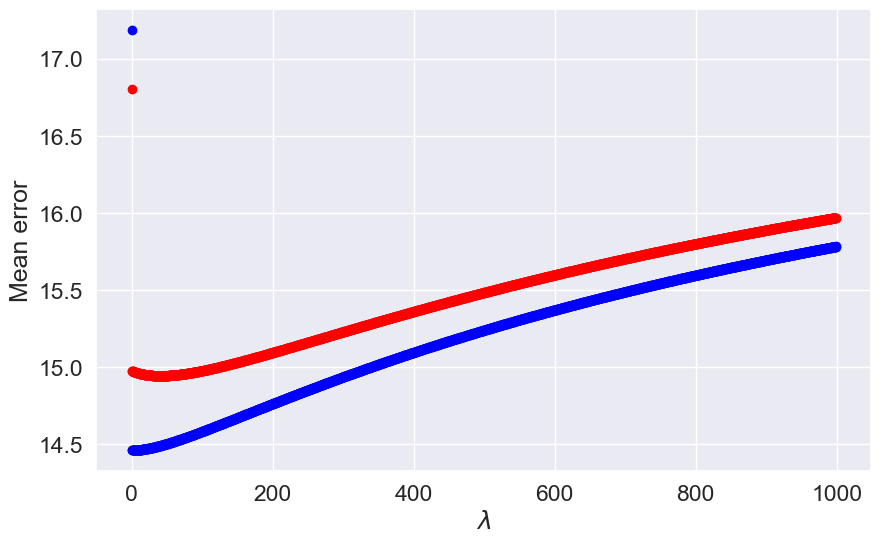

In [96]:

fig, ax = plt.subplots(figsize=(10,6))

ax.scatter(lams, test_error_avgs, c='red')
ax.scatter(lams, train_error_avgs, c='blue')
ax.set_xlabel("$\lambda$")
ax.set_ylabel("Mean error")